# 低显存 OL 训练

## Goal

本 Notebook 从部分 FE checkpoint 中只加载 FE 参数，不加载 FE 的 Adam 状态，然后训练 OL。每隔 500 步只显示三个量：训练 loss、当前训练 batch 的分布内压力相对 $L_2$、固定解析真解的面积加权相对 $L_2$。

OL batch 不生成随机 probe 场；分布内误差直接在当前 batch 的规则极坐标网格上计算。

## Setup

### 1. 在导入 JAX 前设置环境

In [1]:
import os
import sys
from pathlib import Path

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["CUDA_VISIBLE_DEVICES"] = "3"

PROJECT_ROOT = Path.cwd().resolve()
required = ["config_polar.py", "data_polar.py", "models_polar.py", "train_polar.py"]
missing = [name for name in required if not (PROJECT_ROOT / name).exists()]
if missing:
    raise FileNotFoundError("请把 Notebook 放在项目根目录。缺少：" + ", ".join(missing))
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print("Project root:", PROJECT_ROOT)
print("Python:", sys.executable)

Project root: /home/user/data/Hollon/海洋工程水动力/polar_annulus_p_prior_ablation
Python: /home/user/anaconda3/envs/sno/bin/python


### 2. 检查 GPU

In [2]:
import jax

devices = jax.devices()
print("JAX:", jax.__version__)
print("Devices:", devices)
if not any(device.platform in {"gpu", "tpu"} for device in devices):
    raise RuntimeError("JAX 没有检测到 GPU/TPU。")

JAX: 0.9.2
Devices: [CudaDevice(id=0)]


## Steps

### 3. 重建 FE 配置并读取 checkpoint

`VARIANT`、`SEED` 和 FE 输出目录必须与 FE 训练时一致。`OL_SAMPLE_SIZE` 只改变新的 OL 训练 batch，不会修改 FE checkpoint。

In [3]:
import json
from config_polar import make_ablation_config

VARIANT = "p_raw"  # p_rms 实验请改成 "p_rms"
SEED = 0
OL_SAMPLE_SIZE = 32

fe_config = make_ablation_config(
    variant=VARIANT,
    seed=SEED,
    out_dir=PROJECT_ROOT / "out_p_prior_ablation",
)
fe_metadata_path = fe_config.output_dir / "fe_checkpoint_latest.json"
fe_checkpoint_path = fe_config.output_dir / "fe_checkpoint_latest.msgpack"
if not fe_metadata_path.exists() or not fe_checkpoint_path.exists():
    raise FileNotFoundError("找不到 FE checkpoint 的 json/msgpack 文件。")

fe_metadata = json.loads(fe_metadata_path.read_text(encoding="utf-8"))
saved_fe_step = int(fe_metadata["completed_steps"])
assert fe_metadata["stage"] == "fe"
assert fe_metadata["config_fingerprint"] == fe_config.fingerprint(), (
    "当前配置与 FE checkpoint 指纹不一致。"
)
print("FE directory:", fe_config.output_dir)
print("FE checkpoint step:", saved_fe_step)
print("FE effective batch size:", fe_config.effective_batch_size)

FE directory: /home/user/data/Hollon/海洋工程水动力/polar_annulus_p_prior_ablation/out_p_prior_ablation/polar_p_raw_seed0
FE checkpoint step: 100000
FE effective batch size: 768


### 4. 只加载 FE 参数

该步骤不会在 GPU 上创建 FE 优化器，因此不会加载约两倍参数量的 Adam 一阶和二阶状态。

In [4]:
from train_polar import load_fe_inference_state

fe_inference_state, normalizer = load_fe_inference_state(fe_config)
assert not hasattr(fe_inference_state, "opt_state")
print("FE parameter-only state loaded.")
print("Normalizer:", normalizer)

FE parameter-only state loaded.
Normalizer: FieldNormalizer(mean_p=Array(0., dtype=float32), std_p=Array(0.46459, dtype=float32), mean_f=Array(-0.01010508, dtype=float32), std_f=Array(23.433538, dtype=float32))


### 5. 建立独立的低显存 OL 目录

In [5]:
from dataclasses import replace
from train_polar import save_normalizer, save_params

ol_run_name = "polar_p_raw_seed0"
ol_config = replace(
    fe_config,
    run_name=ol_run_name,
    sample_size=OL_SAMPLE_SIZE,
    ol_log_interval=500,
)
ol_config.save_json()

provenance = {
    "source_fe_directory": str(fe_config.output_dir),
    "source_fe_checkpoint": str(fe_checkpoint_path),
    "source_fe_config_fingerprint": fe_config.fingerprint(),
    "source_fe_completed_steps": saved_fe_step,
    "ol_config_fingerprint": ol_config.fingerprint(),
    "ol_sample_size": OL_SAMPLE_SIZE,
    "ol_effective_batch_size": ol_config.effective_batch_size,
    "monitoring": "current training batch plus fixed analytic solution",
}
provenance_path = ol_config.output_dir / "fe_snapshot_provenance.json"
if provenance_path.exists():
    existing = json.loads(provenance_path.read_text(encoding="utf-8"))
    assert existing == provenance, "现有 OL 目录属于其他配置，请更换 run_name。"
else:
    provenance_path.write_text(
        json.dumps(provenance, indent=2, ensure_ascii=False),
        encoding="utf-8",
    )
save_params(fe_inference_state.params, ol_config.output_dir / "fe_params.msgpack")
save_normalizer(normalizer, ol_config.output_dir)
print("OL directory:", ol_config.output_dir)
print("OL effective batch size:", ol_config.effective_batch_size)
print("Log interval:", ol_config.ol_log_interval)

OL directory: /home/user/data/Hollon/海洋工程水动力/polar_annulus_p_prior_ablation/out_p_prior_ablation/polar_p_raw_seed0
OL effective batch size: 384
Log interval: 500


### 6. 训练 OL

每 500 步打印：

- `loss`：当前 batch 的 latent MSE；
- `in_dist_RL2(P)`：同一个当前 batch 在规则极坐标网格上的压力相对 $L_2$；
- `exact_RL2(P)`：$f=0$、$g_n=\cos\theta$、$k=1$ 解析真解的面积加权相对 $L_2$。

In [6]:
from train_polar import train_operator

ol_state = train_operator(
    ol_config,
    fe_inference_state,
    normalizer,
    resume=True,
)

[OL monitor] every 500 steps: loss, current-batch RL2(P), exact RL2(P).


Operator training:   0%|                                                                                      …

[OL 0000500] loss=1.4295e-02 in_dist_RL2(P)=4.1968e-01 exact_RL2(P)=1.4119e+00 elapsed=227.8s
[OL 0001000] loss=5.1912e-03 in_dist_RL2(P)=2.5635e-01 exact_RL2(P)=1.2654e+00 elapsed=413.0s
[OL 0001500] loss=2.8145e-03 in_dist_RL2(P)=1.4720e-01 exact_RL2(P)=8.4511e-01 elapsed=599.9s
[OL 0002000] loss=2.0274e-03 in_dist_RL2(P)=1.5199e-01 exact_RL2(P)=1.0653e+00 elapsed=787.2s
[OL 0002500] loss=1.5013e-03 in_dist_RL2(P)=1.3227e-01 exact_RL2(P)=5.0226e-01 elapsed=974.1s
[OL 0003000] loss=1.3777e-03 in_dist_RL2(P)=1.4288e-01 exact_RL2(P)=9.3002e-01 elapsed=1161.0s
[OL 0003500] loss=8.9087e-04 in_dist_RL2(P)=9.5922e-02 exact_RL2(P)=7.9833e-01 elapsed=1347.8s
[OL 0004000] loss=6.0033e-04 in_dist_RL2(P)=6.9874e-02 exact_RL2(P)=5.4175e-01 elapsed=1535.0s
[OL 0004500] loss=8.0183e-04 in_dist_RL2(P)=9.5605e-02 exact_RL2(P)=9.7425e-01 elapsed=1721.9s
[OL 0005000] loss=5.4051e-04 in_dist_RL2(P)=7.2003e-02 exact_RL2(P)=6.1167e-01 elapsed=1910.0s
[OL 0005500] loss=6.9666e-04 in_dist_RL2(P)=9.9137e-02 

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



[OL 0082000] loss=1.6148e-04 in_dist_RL2(P)=4.3677e-02 exact_RL2(P)=3.7221e-01 elapsed=30666.1s
[OL 0082500] loss=2.4399e-04 in_dist_RL2(P)=4.2674e-02 exact_RL2(P)=2.2185e-01 elapsed=30852.5s


IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



[OL 0137000] loss=9.1441e-05 in_dist_RL2(P)=3.0724e-02 exact_RL2(P)=1.3525e-01 elapsed=51209.7s
[OL 0137500] loss=7.7749e-05 in_dist_RL2(P)=2.5847e-02 exact_RL2(P)=1.0272e-01 elapsed=51396.6s
[OL 0138000] loss=1.0902e-04 in_dist_RL2(P)=3.1240e-02 exact_RL2(P)=1.6437e-01 elapsed=51583.5s
[OL 0138500] loss=1.6841e-04 in_dist_RL2(P)=2.7349e-02 exact_RL2(P)=1.1867e-01 elapsed=51770.5s
[OL 0139000] loss=1.7688e-04 in_dist_RL2(P)=3.3450e-02 exact_RL2(P)=1.6132e-01 elapsed=51957.4s
[OL 0139500] loss=8.8357e-05 in_dist_RL2(P)=2.7657e-02 exact_RL2(P)=9.5576e-02 elapsed=52144.4s
[OL 0140000] loss=9.5247e-05 in_dist_RL2(P)=3.0128e-02 exact_RL2(P)=2.2525e-01 elapsed=52331.3s
[OL 0140500] loss=1.0724e-04 in_dist_RL2(P)=2.8951e-02 exact_RL2(P)=1.5108e-01 elapsed=52519.2s
[OL 0141000] loss=8.9472e-05 in_dist_RL2(P)=2.7530e-02 exact_RL2(P)=1.2514e-01 elapsed=52705.8s


KeyboardInterrupt: 

## Checks

### 7. 查看学习曲线

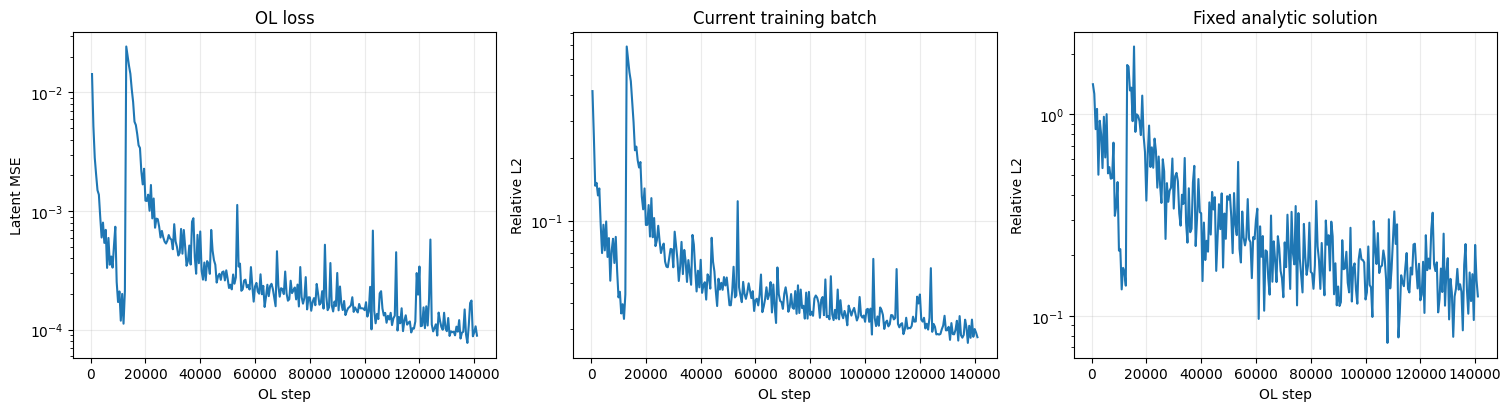

In [7]:
import matplotlib.pyplot as plt
import numpy as np

history_path = ol_config.output_dir / "operator_training_history.npz"
history = np.load(history_path)
steps = history["step"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
series = [
    ("loss", "Latent MSE", "OL loss"),
    ("in_distribution_relative_l2", "Relative L2", "Current training batch"),
    ("exact_relative_l2", "Relative L2", "Fixed analytic solution"),
]
for axis, (name, ylabel, title) in zip(axes, series):
    axis.semilogy(steps, history[name])
    axis.set(xlabel="OL step", ylabel=ylabel, title=title)
    axis.grid(alpha=0.25)
plt.show()

## Next Steps

- OL 中断后重新启动 Kernel，从顶部运行，并保持相同的 `OL_SAMPLE_SIZE` 和 `run_name`；`resume=True` 会读取最近的 OL checkpoint。
- 如果真正进入训练步后仍然 OOM，再把 `OL_SAMPLE_SIZE` 从 8 降到 4，并使用新的 `run_name`。
- 不要把该目录的 checkpoint 与其他 batch size 或其他 FE 步数的 OL 实验混用。